# Multi-Sensor Forest Monitoring in Ecuador (Part 1/3): Image Download

**Monitoring Deforestation in Chocó Andino Biosphere Reserve using Sentinel-2 and Landsat**

---


## 📚 Series Overview

This is **Part 1** of a 3-part tutorial series on multi-sensor satellite image analysis for forest monitoring:

- **Part 1 (this notebook)**: Download and explore satellite imagery
- **Part 2**: Harmonize and create monthly composites
- **Part 3**: Deep learning-based change detection

## 🎯 Part 1 Objectives

In this notebook, we will:
1. Define our study area (Chocó Andino de Pichincha, Ecuador)
2. Connect to Microsoft Planetary Computer STAC API
3. Search for available Sentinel-2 and Landsat images
4. Analyze cloud cover patterns
5. Download imagery for 2024-2025

## 🌳 Study Area: Chocó Andino de Pichincha

The Chocó Andino de Pichincha Biosphere Reserve (UNESCO, 2018) is located in northern Ecuador, northwest of Quito. This region is part of the Chocó-Darién biodiversity hotspot and faces significant deforestation pressure from agriculture, logging, and urban expansion.

**Key Facts:**
- **Size**: 286,806 hectares (~2,868 km²)
- **Location**: Pichincha Province, Ecuador
- **Elevation**: 360m - 4,480m above sea level
- **Biodiversity**: Over 600 bird species, cloud forests, montane ecosystems
- **Threats**: Agricultural expansion, illegal logging, road construction

**Reference**: [UNESCO MAB - Chocó Andino](https://www.unesco.org/en/mab/choco-andino-de-pichincha)


## 1. Setup and Imports

First, we'll import all necessary libraries for:
- Geospatial data handling (geopandas, shapely)
- STAC API access (pystac-client, planetary-computer)
- Data loading (odc-stac, xarray)
- Visualization (matplotlib, hvplot, geoviews)

In [82]:
# Geospatial libraries
import geopandas as gpd
from shapely.geometry import box


# STAC and data access
from pystac_client import Client
import planetary_computer
from odc.stac import stac_load

# Data handling
import xarray as xr
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import hvplot.pandas
import geoviews as gv
import notebook_utils.utils_download_image as udi
#contextily
import contextily
gv.extension('bokeh')

# System utilities
import os
import importlib
importlib.reload(udi)
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Connect to Planetary Computer STAC API

**What is STAC?**
- STAC (SpatioTemporal Asset Catalog) is a standardized way to describe geospatial data
- Microsoft Planetary Computer hosts petabytes of free satellite imagery
- No API key required for search (required for large-scale downloading)

We'll connect to the catalog and sign requests for data access.

In [83]:
# Connect to Planetary Computer STAC catalog
catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace  # Sign requests for data access
)

print("✅ Connected to Microsoft Planetary Computer")
print(f"📦 Available collections: {len(list(catalog.get_collections()))}")

✅ Connected to Microsoft Planetary Computer
📦 Available collections: 135


In [84]:
# Get all collections
collections = list(catalog.get_collections())

print(f"Number of collections : {len(collections)}")
    
# Filter Sentinel-2 and Landsat
for collection in collections:
    if 'sentinel-2' in collection.id.lower() or 'landsat' in collection.id.lower():
        print(f"\n🛰️ {collection.id}")
        print(f"   {collection.title}")

Number of collections : 135

🛰️ landsat-c2-l2
   Landsat Collection 2 Level-2

🛰️ sentinel-2-l2a
   Sentinel-2 Level-2A

🛰️ landsat-c2-l1
   Landsat Collection 2 Level-1


## 3. Define Study Area

We'll focus on a **priority corridor** within the Chocó Andino:
- **Pacto-Nanegal corridor**: High deforestation activity
- **Bbox**: [-78.9, 0.0, -78.5, 0.4]
- **Area**: ~1,800 km²

This smaller area allows for:
- Faster processing and downloads
- Focus on active deforestation zones
- Manageable data size for tutorial purposes

In [85]:
# Define bounding box (West, South, East, North)
lon_min, lon_max = -78.9, -78.5  # Longitude range
lat_min, lat_max = 0.0, 0.4      # Latitude range

bbox = (lon_min, lat_min, lon_max, lat_max)

# Create geometry for the study area
bbox_geom = box(*bbox)
study_area = gpd.GeoDataFrame(
    [1], 
    geometry=[bbox_geom], 
    crs='EPSG:4326'
)
study_area['name'] = 'Chocó Andino - Pacto Corridor'


print(f"📍 Study Area Coordinates:")
print(f"   Longitude: {lon_min}° to {lon_max}° E")
print(f"   Latitude: {lat_min}° to {lat_max}° N")


📍 Study Area Coordinates:
   Longitude: -78.9° to -78.5° E
   Latitude: 0.0° to 0.4° N


### 3.1 Visualize Study Area

Let's plot our study area on a satellite basemap to see the context.

In [86]:
# Create interactive map with satellite imagery
tiles_sat = gv.tile_sources.EsriImagery
tiles_labels = gv.tile_sources.EsriWorldBoundariesAndPlaces

# Plot study area
plot = tiles_sat * tiles_labels * study_area.hvplot(
    geo=True, 
    fill_alpha=0, 
    line_color='red', 
    line_width=3,
    frame_height=500, 
    frame_width=700, 
    title='Study Area: Chocó Andino - Pacto Corridor',
    hover_cols=['name']
)
plot

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .WMTS.II    :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]   (name)

## 4. Define Temporal Range

We'll download imagery from **2024-2025** to enable:
- **Baseline year (2024)**: Full year of data for reference
- **Current year (2025)**: Ongoing monitoring

This allows us to detect recent deforestation and track changes over time.

In [87]:
# Define temporal range
start_date = "2024-01-01"
end_date = "2026-01-01"  # Includes all of 2025
time_range = f"{start_date}/{end_date}"

print(f"📅 Temporal Range: {time_range}")
print(f"   Start: {start_date}")
print(f"   End: {end_date}")


📅 Temporal Range: 2024-01-01/2026-01-01
   Start: 2024-01-01
   End: 2026-01-01


## 5. Search Available Imagery

Now we'll search for all available images in our study area and time range.

**Search Parameters:**
- **Collections**: `landsat-c2-l2` (Landsat 8/9) and `sentinel-2-l2a` (Sentinel-2)
- **Cloud Cover Filter**: < 90% (we'll filter more strictly later)
- **Spatial Filter**: Our study area bounding box

**Why 90% cloud threshold?**
Even heavily clouded scenes can have useful clear pixels in specific areas. We'll analyze cloud cover distribution after downloading.

In [88]:
# Search Landsat 8/9 Collection 2 Level-2 imagery
search_landsat = catalog.search(
    collections=["landsat-c2-l2"], intersects=bbox_geom, datetime=time_range,   query={"eo:cloud_cover": {"lt": 90}}
)
# Search Sentinel-2 Level-2A imagery
search_sentinel = catalog.search(
    collections=["sentinel-2-l2a"], intersects=bbox_geom, datetime=time_range,   query={"eo:cloud_cover": {"lt": 90}}
)

### 5.1 Collect Search Results

In [89]:
# Retrieve search results
landsat_items = search_landsat.item_collection()
sentinel_items = search_sentinel.item_collection()

print(f"\n📊 Search Results:")
print(f"   🛰️ Landsat: {len(landsat_items)} images found")
print(f"   🛰️ Sentinel-2: {len(sentinel_items)} images found")
print(f"   📸 Total: {len(landsat_items) + len(sentinel_items)} images")
print(f"\n💡 This represents {len(landsat_items) + len(sentinel_items)} potential observations over 2 years")


📊 Search Results:
   🛰️ Landsat: 78 images found
   🛰️ Sentinel-2: 235 images found
   📸 Total: 313 images

💡 This represents 313 potential observations over 2 years


## 6. Analyze Cloud Cover Patterns

Tropical regions like Ecuador have persistent cloud cover. Let's analyze:
- Cloud cover distribution over time
- How many usable images we have
- Seasonal patterns

This helps us understand data availability and plan our compositing strategy.

In [90]:
df_landsat = gpd.GeoDataFrame.from_features(landsat_items.to_dict(), crs="epsg:4326")
df_sentinel = gpd.GeoDataFrame.from_features(sentinel_items.to_dict(), crs="epsg:4326")

In [91]:
# Filter the Landsat dataframe to keep only the relevant columns
df_landsat_filter = df_landsat[['datetime','platform','eo:cloud_cover']].reset_index(drop=True)

In [92]:
# Filter the Sentinel dataframe to keep only the relevant columns
df_sentinel_filter = df_sentinel[['datetime','platform','eo:cloud_cover']].reset_index(drop=True)

In [93]:
# Combine the two dataframes and sort by datetime
df_all_image = pd.concat([df_landsat_filter, df_sentinel_filter])
df_all_image.sort_values(by='datetime', inplace=True)
df_all_image.head(10)

,datetime,platform,eo:cloud_cover
234,2024-01-06T15:36:29.024000Z,Sentinel-2B,79.213989
233,2024-01-06T15:36:29.024000Z,Sentinel-2B,82.568085
77,2024-01-11T12:52:25.130287Z,landsat-7,48.000000
76,2024-01-11T15:26:25.676024Z,landsat-8,60.280000
231,2024-01-11T15:36:21.024000Z,Sentinel-2A,69.259626
232,2024-01-11T15:36:21.024000Z,Sentinel-2A,64.903378
75,2024-01-16T12:54:41.271962Z,landsat-7,0.000000
74,2024-01-19T15:26:33.807441Z,landsat-9,74.910000
230,2024-01-21T15:36:21.024000Z,Sentinel-2A,88.412791
229,2024-01-26T15:36:29.024000Z,Sentinel-2B,38.347930


### 6.1 Cloud Cover Statistics

In [94]:
# Overall statistics
print("☁️ Cloud Cover Statistics:")
print("="*50)
print(f"   Mean cloud cover: {df_all_image['eo:cloud_cover'].mean():.1f}%")
print(f"   Median cloud cover: {df_all_image['eo:cloud_cover'].median():.1f}%")
print(f"   Min cloud cover: {df_all_image['eo:cloud_cover'].min():.1f}%")
print(f"   Max cloud cover: {df_all_image['eo:cloud_cover'].max():.1f}%")

☁️ Cloud Cover Statistics:
   Mean cloud cover: 65.9%
   Median cloud cover: 70.1%
   Min cloud cover: 0.0%
   Max cloud cover: 89.9%


In [95]:
# Count usable images at different cloud thresholds
thresholds = [10, 30, 50, 70]
total = len(df_all_image)

print("\n📈 Usable Images by Cloud Cover Threshold:")
print("="*50)

for threshold in thresholds:
    count = len(df_all_image[df_all_image['eo:cloud_cover'] < threshold])
    percentage = (count / total) * 100
    print(f"   < {threshold:2d}% cloud: {count:3d} images ({percentage:5.1f}%)")

print(f"\n💡 Insight: Only {(len(df_all_image[df_all_image['eo:cloud_cover'] < 50]) / total * 100):.1f}% of images have <50% cloud cover")
print("   This is typical for tropical regions!")


📈 Usable Images by Cloud Cover Threshold:
   < 10% cloud:   2 images (  0.6%)
   < 30% cloud:  14 images (  4.5%)
   < 50% cloud:  59 images ( 18.8%)
   < 70% cloud: 155 images ( 49.5%)

💡 Insight: Only 18.8% of images have <50% cloud cover
   This is typical for tropical regions!


### 6.2 Temporal Cloud Cover Visualization

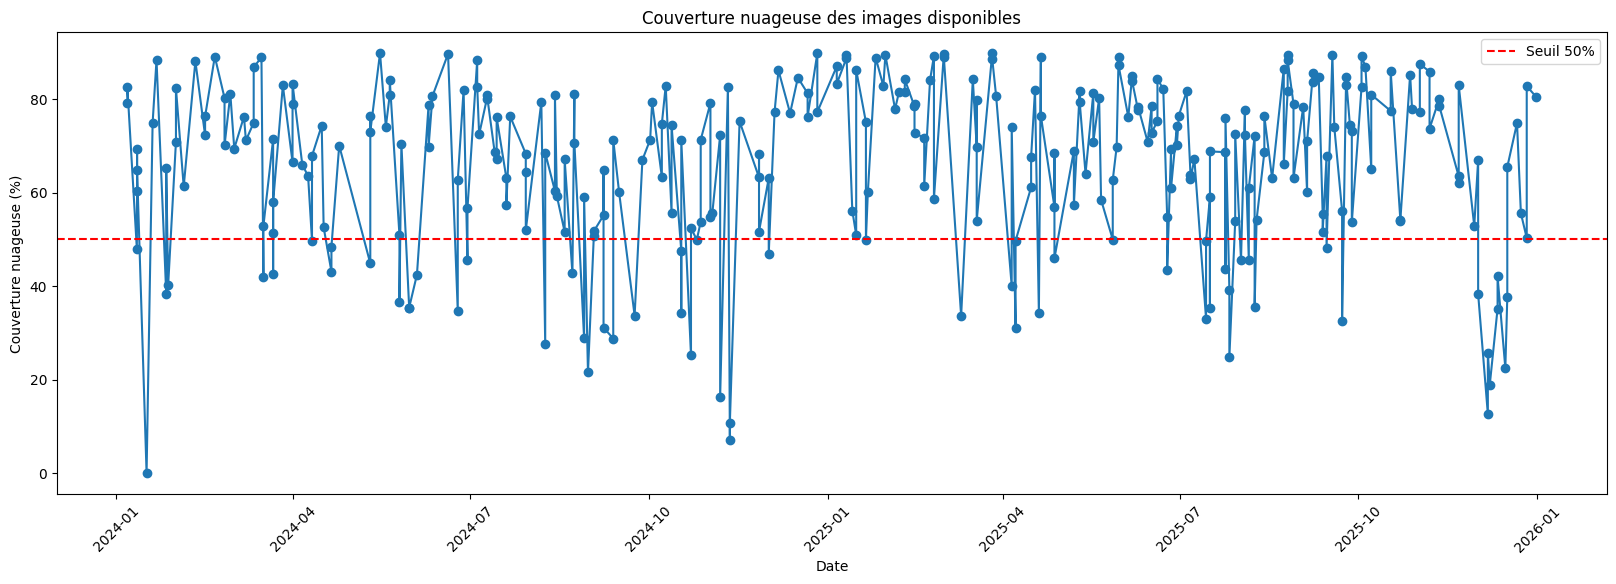

In [96]:
# Visualize cloud cover over time
plt.figure(figsize=(20, 6))
plt.plot(pd.to_datetime(df_all_image['datetime']), df_all_image['eo:cloud_cover'], marker='o')
plt.axhline(50, color='red', linestyle='--', label='Seuil 50%')
plt.title("Couverture nuageuse des images disponibles")
plt.xlabel("Date")
plt.ylabel("Couverture nuageuse (%)")
plt.xticks(rotation=45)
plt.legend()
plt.show()


As observed, most images have a cloud cover greater than 50%, which is not ideal for our analysis. Our goal is to create a monthly composite image of the area, so we will analyze the monthly statistics of usable images (with less than 90% cloud cover) to determine if a monthly composite image is feasible with the available data.

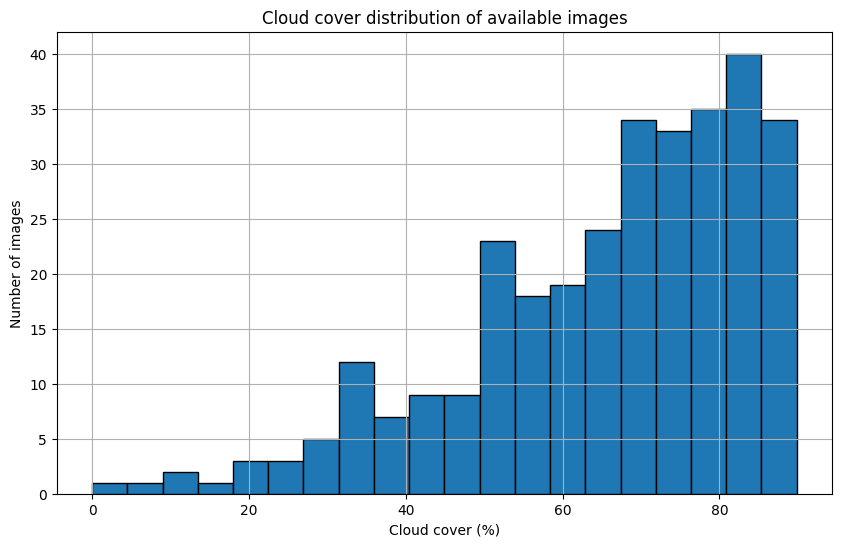

In [97]:
plt.figure(figsize=(10, 6))
df_all_image['eo:cloud_cover'].hist(bins=20, edgecolor='black')
plt.title("Cloud cover distribution of available images")
plt.xlabel("Cloud cover (%)")
plt.ylabel("Number of images")
plt.show()

### 6.3 Monthly Distribution Analysis

Let's analyze how many usable images we have per month. This determines if monthly composites are feasible.

In [98]:
# monthly statistics of usable images (with less than 90% cloud cover)
df_all_image['month'] = pd.to_datetime(df_all_image['datetime']).dt.to_period('M')
df_all_image['monthly_images'] = df_all_image['month'].map(df_all_image['month'].value_counts())
df_all_image['cloud_cover_monthly'] = df_all_image.groupby('month')['eo:cloud_cover'].transform('mean')
df_all_image['monthly_>50'] = df_all_image['month'].map(df_all_image[df_all_image['eo:cloud_cover'] < 50].groupby('month').size())

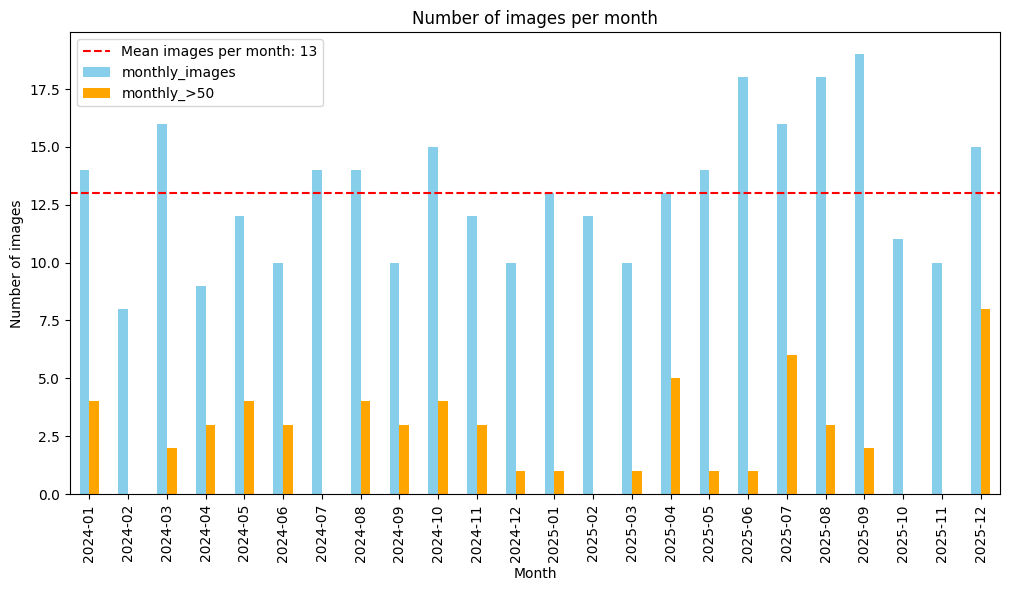

In [99]:
df_monthly = df_all_image.groupby('month').agg({'monthly_images':'first', 'cloud_cover_monthly':'first', 'monthly_>50':'first'}).reset_index()
mean_monthly_image = int(df_monthly['monthly_images'].mean())
plt.figure(figsize=(12, 6))
df_monthly.set_index('month')[['monthly_images', 'monthly_>50']].plot(
    kind='bar', color=['skyblue', 'orange'], ax=plt.gca()
)
plt.axhline(mean_monthly_image, color='red', linestyle='--', label=f'Mean images per month: {mean_monthly_image}')
plt.title("Number of images per month")
plt.xlabel("Month")
plt.ylabel("Number of images")
plt.legend()
plt.show()

<Figure size 1200x600 with 0 Axes>

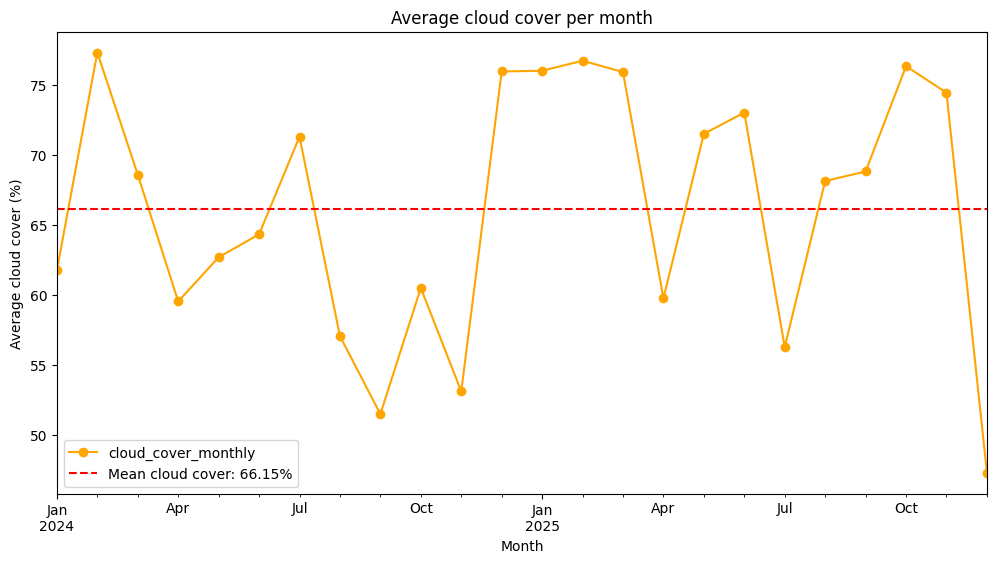

In [100]:
plt.figure(figsize=(12, 6))
df_monthly.plot(x='month', y='cloud_cover_monthly', kind='line', marker='o', figsize=(12, 6), color='orange')
cloud_cover_mean = df_monthly['cloud_cover_monthly'].mean()
plt.axhline(cloud_cover_mean, color='red', linestyle='--', label=f'Mean cloud cover: {cloud_cover_mean:.2f}%')
plt.title("Average cloud cover per month")
plt.xlabel("Month")
plt.ylabel("Average cloud cover (%)")
plt.legend()
plt.show()

In [101]:
df_monthly.describe()

,monthly_images,cloud_cover_monthly,monthly_>50
count,24.000000,24.000000,19.000000
mean,13.041667,66.153912,3.105263
std,3.014157,9.070343,1.882514
min,8.000000,47.288195,1.000000
25%,10.000000,59.686665,1.500000
50%,13.000000,68.354266,3.000000
75%,15.000000,74.813877,4.000000
max,19.000000,77.315977,8.000000


As observed in our monthly statistics, the number of images per month is quite variable, with some months having a higher number of images than others. The average cloud cover also fluctuates, which can impact the usability of the images for analysis. It's important to consider these factors when planning satellite image-based projects in this area. We also observe that the minimum cloud cover is around 47% and the maximum is around 77%, which means the area is often cloudy. We will try to create a monthly composite image.

## 7. Display images 

In [102]:
print(f"List band landsat: {list(landsat_items[0].assets.keys())}")
print(f"List band sentinel: {list(sentinel_items[0].assets.keys())}")

List band landsat: ['qa', 'ang', 'red', 'blue', 'drad', 'emis', 'emsd', 'trad', 'urad', 'atran', 'cdist', 'green', 'nir08', 'lwir11', 'swir16', 'swir22', 'coastal', 'mtl.txt', 'mtl.xml', 'mtl.json', 'qa_pixel', 'qa_radsat', 'qa_aerosol', 'tilejson', 'rendered_preview']
List band sentinel: ['AOT', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B11', 'B12', 'B8A', 'SCL', 'WVP', 'visual', 'safe-manifest', 'granule-metadata', 'inspire-metadata', 'product-metadata', 'datastrip-metadata', 'tilejson', 'rendered_preview']


🎨 Création d'une composition RGB...
(1475, 1485) (1475, 1485) (1475, 1485)


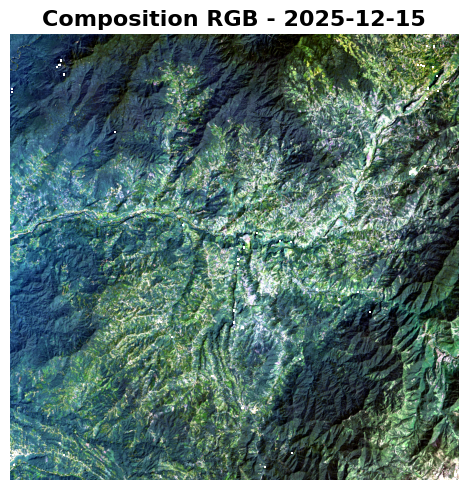

In [103]:

udi.display_image(landsat_items[1], ['red', 'green', 'blue'], bbox=bbox)

🎨 Création d'une composition RGB...
(4425, 4455) (4425, 4455) (4425, 4455)


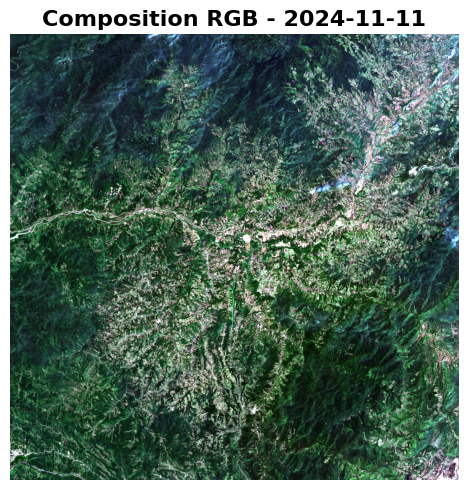

In [104]:
udi.display_image(sentinel_items[143], ['B04', 'B03', 'B02'], bbox=bbox)

We chose images with litle cloud cover to have a better view of the area. You can also observe that that the sentinel 2 as better quality we can  identify more detail that in the landsat image. That is due the the better spatiale resolution of sentinel 2.

### 8. RGB bands statistics

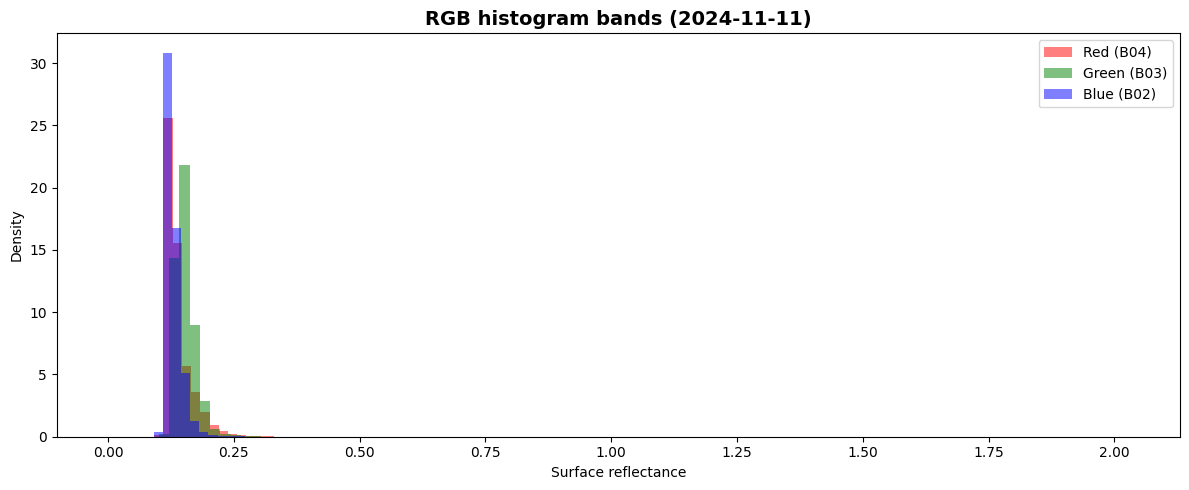

Red   — min: 0.0000 | max: 1.8352 | mean: 0.1394
Green — min: 0.0001 | max: 2.0288 | mean: 0.1541
Blue  — min: 0.0000 | max: 1.8160 | mean: 0.1298


In [105]:
importlib.reload(udi)
udi.display_histogram(item=sentinel_items[143], rgb_name=['B04', 'B03', 'B02'], bbox=bbox)

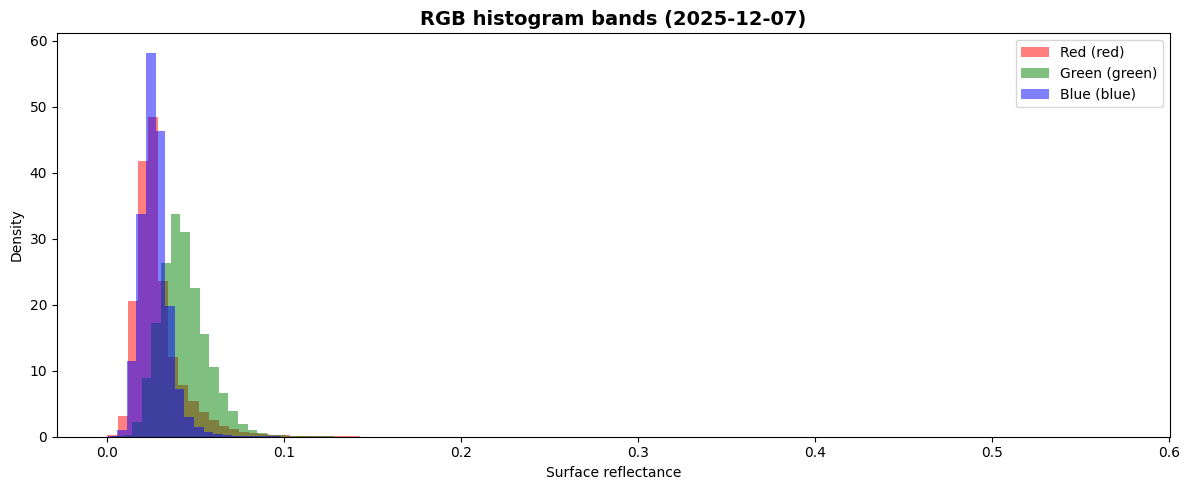

Red   — min: 0.0000 | max: 0.5720 | mean: 0.0287
Green — min: 0.0031 | max: 0.5470 | mean: 0.0435
Blue  — min: 0.0001 | max: 0.5429 | mean: 0.0271


In [106]:
udi.display_histogram(item=landsat_items[2], rgb_name=['red', 'green', 'blue'], bbox=bbox)

We can notice in the statistics that we have some outliers presents in our images that we will have to remove afterward.

### 9. Dowload images

Before downloading the monthly composite image, we will create the harmonized Landsat-Sentinel dataset step by step.

The first step is resampling all images to the same spatial resolution. The best practice is to resample Sentinel-2 down to 30m to match Landsat. Note that interpolation method matters: reflectance bands use bilinear interpolation, while the SCL cloud mask must use nearest neighbor to preserve class labels.

The second step is pairing the spectral bands between both sensors. Landsat and Sentinel-2 do not measure exactly the same wavelengths. A key point here is to use B8A (865nm) instead of B08 (842nm) for the NIR band, as B8A is the correct spectral match for Landsat NIR.

The last step is applying a radiometric correction. Even after scaling to surface reflectance, the same forest pixel will return slightly different values in Landsat vs Sentinel-2 due to differences in band width and spectral response functions. We apply the HLS linear coefficients from Roy et al. (2016) to convert Sentinel-2 values into the Landsat radiometric space, making both sensors directly comparable in a single time series.

1. Cloud masking  (SCL for S2, qa_pixel for Landsat)
2. Resampling     (S2 → 30m)
3. Band pairing   (B8A not B08 for NIR)
4. HLS coefficients (S2 → Landsat radiometric space)
5. Composite


#### 9.1 Cloud masking

In [107]:
s2_data = stac_load(
    sentinel_items,
    bbox=bbox,
    bands=('B02', 'B03', 'B04', 'B8A', 'B11', 'B12', 'SCL'),  # B8A not B08
    resolution=10,
    chunks={'time': 1, 'y': 2048, 'x': 2048}
)

landsat_data = stac_load(
    landsat_items,
    bbox=bbox,
    bands=('blue', 'green', 'red', 'nir08', 'swir16', 'swir22', 'qa_pixel'),
    resolution=30,
    chunks={'time': 1, 'y': 2048, 'x': 2048}
)

# Sentinel-2: SCL valid classes
# 4=vegetation, 5=bare soil, 6=water, 11=snow
scl = s2_data['SCL']
s2_clear = s2_data[['B02','B03','B04','B8A','B11','B12']].where(
    scl.isin([4, 5, 6, 11])
)

# Landsat: qa_pixel bitmask
# bit 0=fill, bit 3=cloud, bit 4=cloud shadow
qa = landsat_data['qa_pixel']
landsat_clear = landsat_data[['blue','green','red','nir08','swir16','swir22']].where((qa & 0b0000000000011001) == 0)



#### 9.2 Resampling S2 to 30m

In [108]:
# Resample reflectance bands with bilinear (continuous values)
s2_30m = s2_clear.interp(
    y=landsat_data.y,
    x=landsat_data.x,
    method='linear'       
)

# SCL must be resampled separately with nearest (class labels)
scl_30m = scl.interp(
    y=landsat_data.y,
    x=landsat_data.x,
    method='nearest'      
)


#### 9.3 Band Pairing 

In [109]:
s2_renamed = s2_30m.rename({
    'B02': 'blue',
    'B03': 'green',
    'B04': 'red',
    'B8A': 'nir',
    'B11': 'swir1',
    'B12': 'swir2'
})

landsat_renamed = landsat_clear.rename({
    'nir08':  'nir',
    'swir16': 'swir1',
    'swir22': 'swir2'
})


#### 9.4 Radiometric Correction (S2 → Landsat space)

In [110]:
# Claverie et al. (2018) - Table 4: https://www.sciencedirect.com/science/article/pii/S0034425718304139
# Formula: OLI = slope × MSI + offset
HLS_COEFFS = {
    'blue':       {'slope': 0.977,  'intercept': -0.00411},
    'green':      {'slope': 1.005,  'intercept': -0.00093},
    'red':        {'slope': 0.982,  'intercept':  0.00094},
    'nir':        {'slope': 1.001,  'intercept': -0.00029},
    'swir1':      {'slope': 1.001,  'intercept': -0.00015},
    'swir2':      {'slope': 0.996,  'intercept': -0.00097},
}


def apply_hls_coefficients(ds):
    corrected = ds.copy()
    for band, coeffs in HLS_COEFFS.items():
        corrected[band] = ds[band] * coeffs['slope'] + coeffs['intercept']
    return corrected

s2_harmonized = apply_hls_coefficients(s2_renamed)


#### 9.5 Monthly median composite

In [111]:
combined = xr.concat(
    [s2_harmonized, landsat_renamed],
    dim='time').sortby('time')

monthly_composite = combined.resample(time='1ME').median()



In [112]:
monthly_composite

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 24, y: 1476, x: 1487)
Coordinates:
  * time     (time) datetime64[us] 192B 2024-01-31 2024-02-29 ... 2025-12-31
  * y        (y) float64 12kB 4.425e+04 4.422e+04 4.419e+04 ... 60.0 30.0 0.0
  * x        (x) float64 12kB 7.337e+05 7.337e+05 ... 7.783e+05 7.783e+05
Data variables:
    blue     (time, y, x) float32 211MB dask.array<chunksize=(1, 1476, 1487), meta=np.ndarray>
    green    (time, y, x) float32 211MB dask.array<chunksize=(1, 1476, 1487), meta=np.ndarray>
    red      (time, y, x) float32 211MB dask.array<chunksize=(1, 1476, 1487), meta=np.ndarray>
    nir      (time, y, x) float32 211MB dask.array<chunksize=(1, 1476, 1487), meta=np.ndarray>
    swir1    (time, y, x) float32 211MB dask.array<chunksize=(1, 1476, 1487), meta=np.ndarray>
    swir2    (time, y, x) float32 211MB dask.array<chunksize=(1, 1476, 1487), meta=np.ndarray>

In [ ]:
download_dir
monthly_composite.to_netcdf(
    f"{download_dir}/choco_andino_harmonized_composite.nc",
    engine='h5netcdf',
    compute=True
)
